# Time series analysis on the data international airline passengers from 1940 to 1960

# import libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose


# Data fetch from github

In [24]:
url='https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df=pd.read_csv(url)

In [11]:
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [25]:
df.shape

(144, 2)

# plot this data to see trend and seasonality

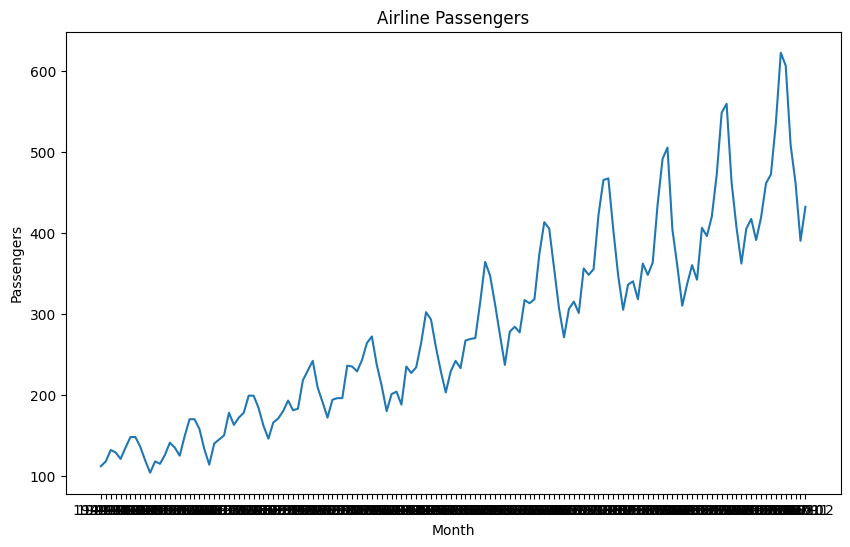

In [26]:
plt.figure(figsize=(10,6))
plt.plot(df['Month'],df['Passengers'])
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.title('Airline Passengers')
plt.show()

# plot this data to see trend and seasonality with seaborn

<Axes: xlabel='Month', ylabel='Passengers'>

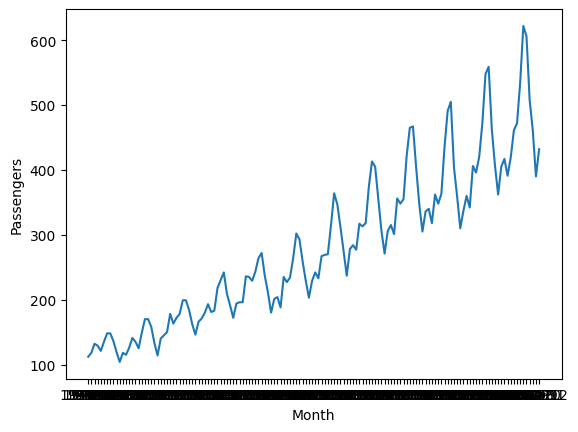

In [27]:
sns.lineplot(x='Month',y='Passengers',data=df)

# Decompose the data into trend ,seasonality and residual

In [28]:
decompose=seasonal_decompose(df['Passengers'],model='multiplicative',period=12)

<Axes: >

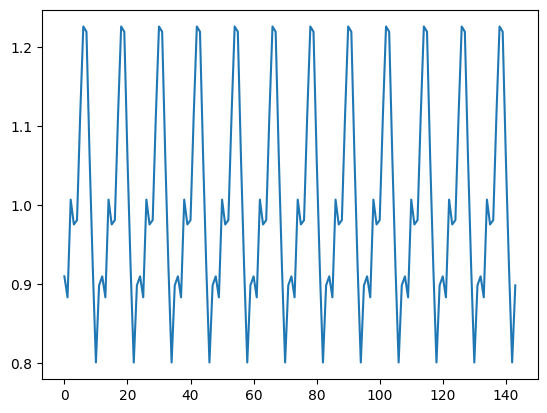

In [29]:
decompose .seasonal.plot()

In [38]:
trend=decompose.trend
seasonal=decompose.seasonal
residual=decompose.resid

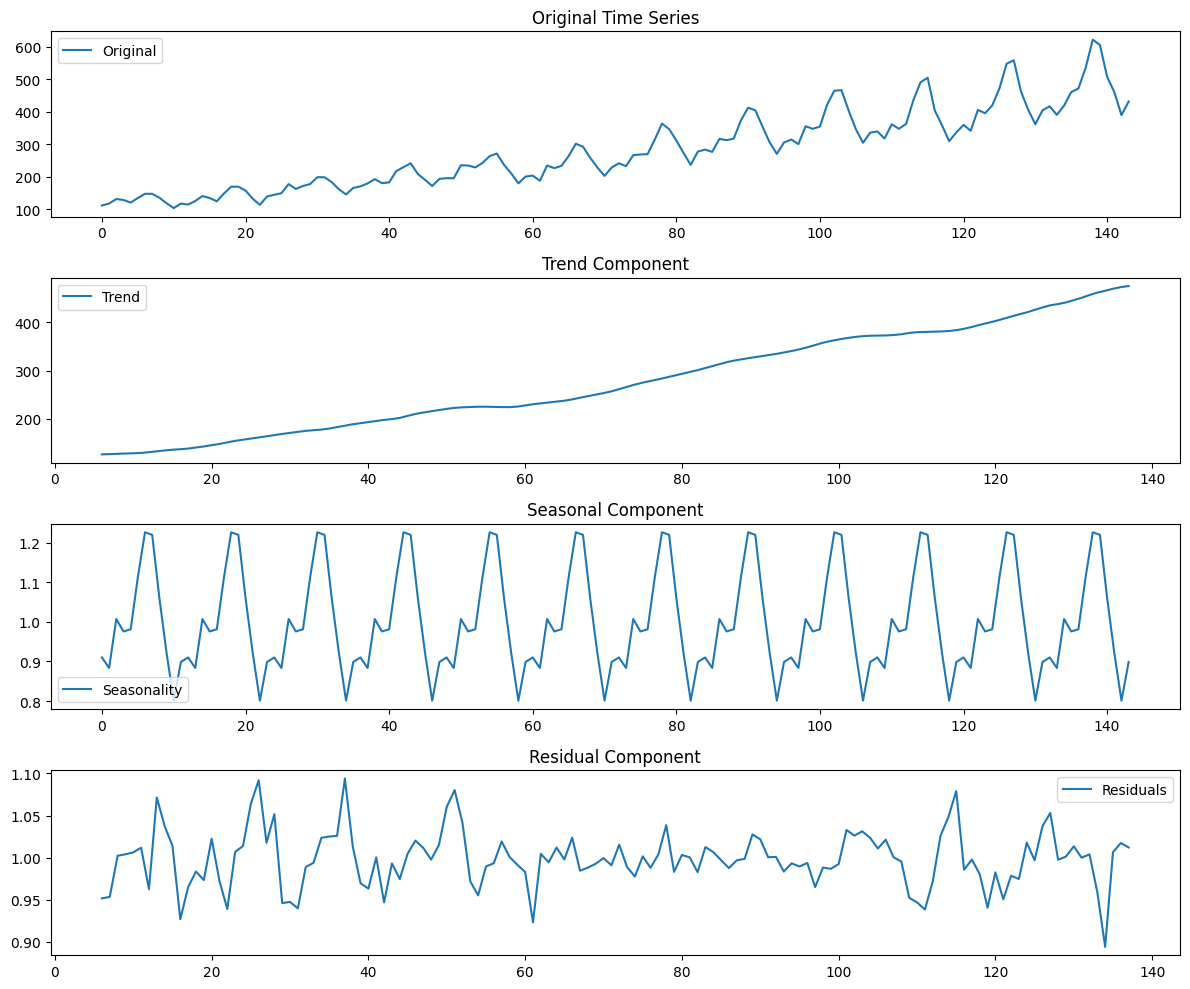

In [39]:
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(df['Passengers'], label='Original')
plt.legend(loc='best')
plt.title('Original Time Series')

plt.subplot(4, 1, 2)
plt.plot(trend, label='Trend')
plt.legend(loc='best')
plt.title('Trend Component')

plt.subplot(4, 1, 3)
plt.plot(seasonal,label='Seasonality')
plt.legend(loc='best')
plt.title('Seasonal Component')

plt.subplot(4, 1, 4)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')
plt.title('Residual Component')

plt.tight_layout()
plt.show()

# to build time series forecasting model for this split the data into training and testing

In [30]:
df['Month'] = pd.to_datetime(df['Month'])
split_index = int(len(df) * 0.8)
train_data = df.iloc[:split_index]
test_data = df.iloc[split_index:]

print(f"Shape of training data: {train_data.shape}")
print(f"Shape of testing data: {test_data.shape}")

Shape of training data: (115, 2)
Shape of testing data: (29, 2)


# fit a simple linear regression model on the training set

In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, nn_predictions)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, nn_predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 155075.58
Root Mean Squared Error (RMSE): 393.80
Mean Absolute Error (MAE): 336.15


# make prediction on the testing set

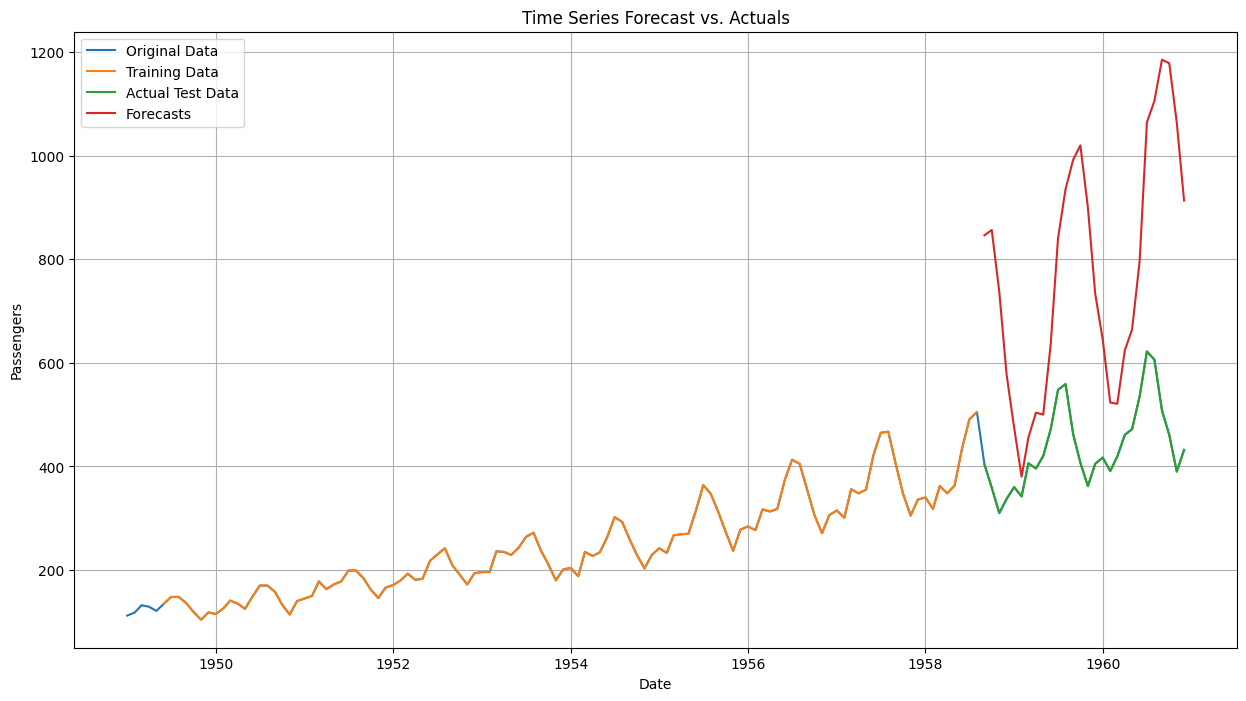

In [37]:
plt.figure(figsize=(15, 8))
plt.plot(df['Month'], df['Passengers'], label='Original Data')
plt.plot(df_cleaned['Month'].iloc[:split_point], y_train, label='Training Data')
plt.plot(df_cleaned['Month'].iloc[split_point:], y_test, label='Actual Test Data')
plt.plot(df_cleaned['Month'].iloc[split_point:], nn_predictions, label='Forecasts')
plt.title('Time Series Forecast vs. Actuals')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
from xgboost import XGBRegressor

# Initialize XGBRegressor model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## Make Predictions with XGBoost

Generate predictions on the test dataset using the trained XGBoost model.


In [40]:
xgb_predictions = xgb_model.predict(X_test)

print("First 10 XGBoost predictions:")
print(xgb_predictions[:10])

First 10 XGBoost predictions:
[429.67566 355.3885  313.30734 335.21848 337.40048 330.16998 422.53995
 428.81808 418.8583  382.94995]


In [41]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, xgb_predictions)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, xgb_predictions)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 4901.35
Root Mean Squared Error (RMSE): 70.01
Mean Absolute Error (MAE): 49.13


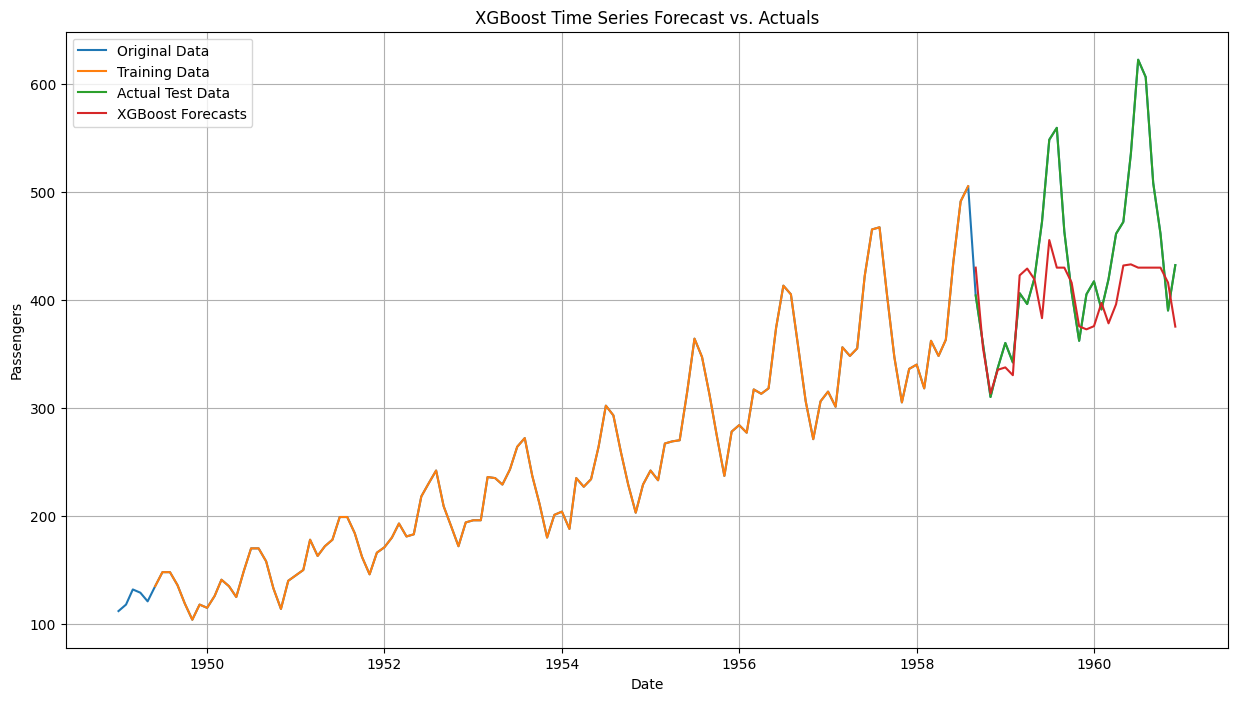

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.plot(df['Month'], df['Passengers'], label='Original Data')
plt.plot(df_cleaned['Month'].iloc[:split_point], y_train, label='Training Data')
plt.plot(df_cleaned['Month'].iloc[split_point:], y_test, label='Actual Test Data')
plt.plot(df_cleaned['Month'].iloc[split_point:], xgb_predictions, label='XGBoost Forecasts')
plt.title('XGBoost Time Series Forecast vs. Actuals')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

## Make Predictions with RandomForest

Generate predictions on the test dataset  X_test using the trained RandomForest model.


In [43]:
rf_predictions = rf_model.predict(X_test)

print("First 10 RandomForest predictions:")
print(rf_predictions[:10])

First 10 RandomForest predictions:
[473.58 436.98 324.81 332.23 343.62 347.87 404.21 411.37 398.97 419.62]


In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, rf_predictions)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, rf_predictions)

print(f"RandomForest Mean Squared Error (MSE): {mse:.2f}")
print(f"RandomForest Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"RandomForest Mean Absolute Error (MAE): {mae:.2f}")

RandomForest Mean Squared Error (MSE): 3497.25
RandomForest Root Mean Squared Error (RMSE): 59.14
RandomForest Mean Absolute Error (MAE): 44.58


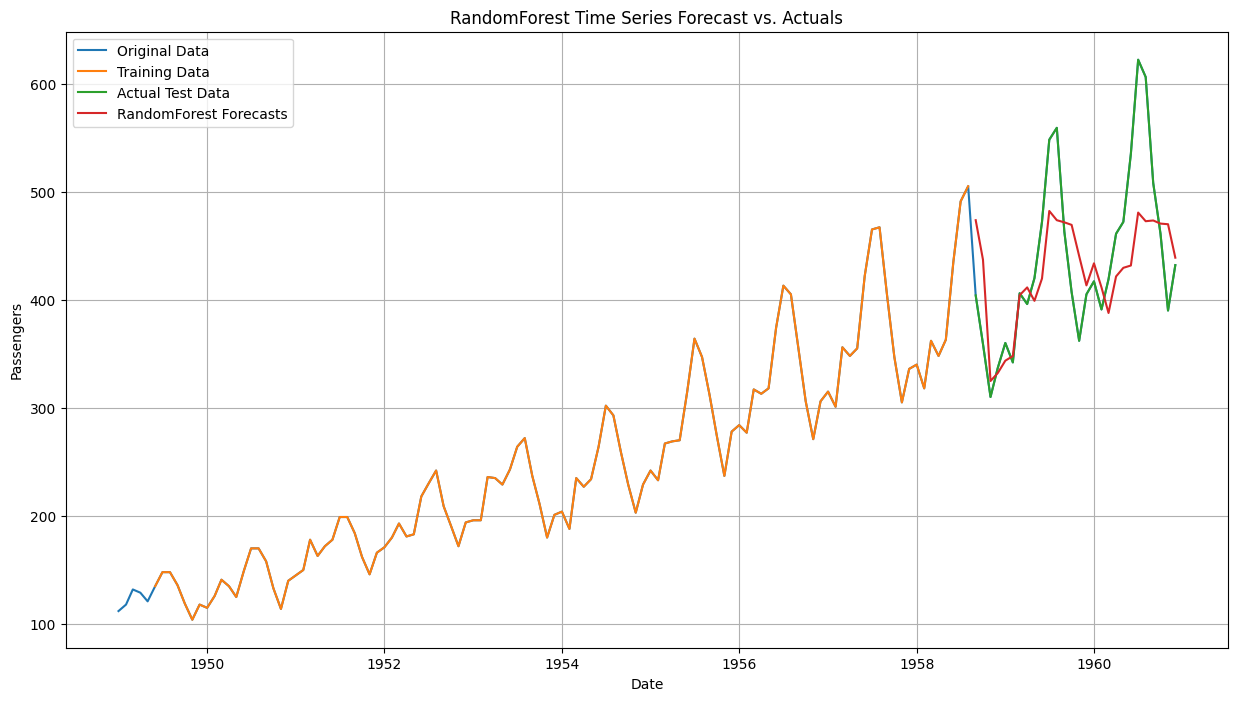

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.plot(df['Month'], df['Passengers'], label='Original Data')
plt.plot(df_cleaned['Month'].iloc[:split_point], y_train, label='Training Data')
plt.plot(df_cleaned['Month'].iloc[split_point:], y_test, label='Actual Test Data')
plt.plot(df_cleaned['Month'].iloc[split_point:], rf_predictions, label='RandomForest Forecasts')
plt.title('RandomForest Time Series Forecast vs. Actuals')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler on X_train and transform both X_train and X_test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (111, 10)
X_test_scaled shape: (28, 10)


In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

print("Neural Network model created and compiled successfully.")
model.summary()

Neural Network model created and compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input # Import Input layer

# Define the neural network model
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)), # Use Input layer instead of input_shape in Dense
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

print("Neural Network model created and compiled successfully.")
model.summary()

Neural Network model created and compiled successfully.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Training Neural Network model...
Neural Network model trained successfully.


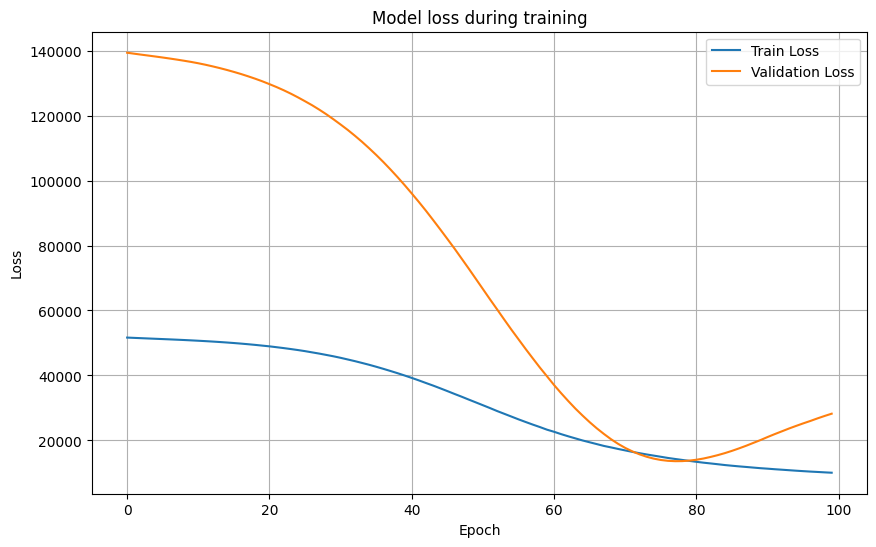

In [49]:
print("Training Neural Network model...")

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=100, # Number of epochs to train for
    batch_size=32, # Batch size for training
    validation_split=0.2, # Use 20% of training data for validation
    verbose=0 # Suppress verbose output during training
)

print("Neural Network model trained successfully.")

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model loss during training')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


In [50]:
print("Making predictions with Neural Network model...")

nn_predictions = model.predict(X_test_scaled).flatten()

print("First 10 Neural Network predictions:")
print(nn_predictions[:20])

Making predictions with Neural Network model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
First 10 Neural Network predictions:
[ 836.3882   859.6593   727.2661   577.2161   466.90103  344.21347
  426.65533  479.9222   460.3193   619.2946   828.0128   898.53235
  969.2398  1012.7761   881.4168   721.2077   623.62994  493.34518
  486.5911   588.0788 ]


In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate Mean Squared Error (MSE)
mse_nn = mean_squared_error(y_test, nn_predictions)

# Calculate Root Mean Squared Error (RMSE)
rmse_nn = np.sqrt(mse_nn)

# Calculate Mean Absolute Error (MAE)
mae_nn = mean_absolute_error(y_test, nn_predictions)

print(f"Neural Network Mean Squared Error (MSE): {mse_nn:.2f}")
print(f"Neural Network Root Mean Squared Error (RMSE): {rmse_nn:.2f}")
print(f"Neural Network Mean Absolute Error (MAE): {mae_nn:.2f}")

Neural Network Mean Squared Error (MSE): 143275.97
Neural Network Root Mean Squared Error (RMSE): 378.52
Neural Network Mean Absolute Error (MAE): 314.49


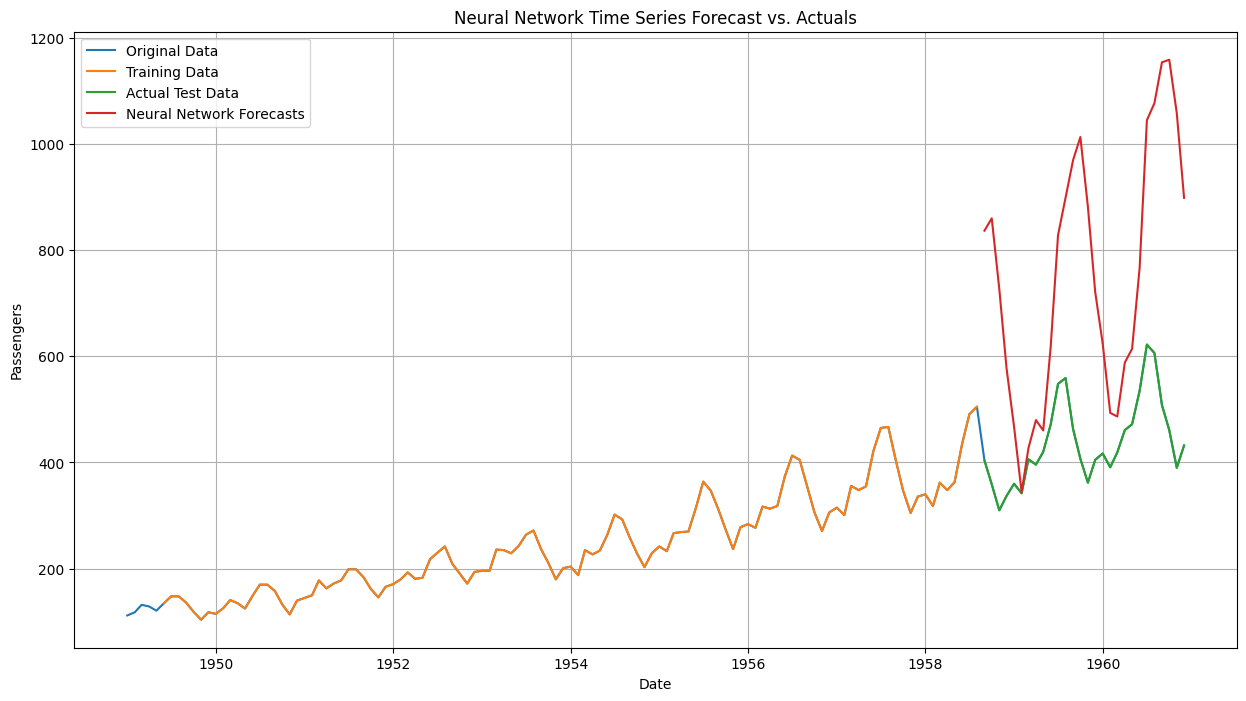

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.plot(df['Month'], df['Passengers'], label='Original Data')
plt.plot(df_cleaned['Month'].iloc[:split_point], y_train, label='Training Data')
plt.plot(df_cleaned['Month'].iloc[split_point:], y_test, label='Actual Test Data')
plt.plot(df_cleaned['Month'].iloc[split_point:], nn_predictions, label='Neural Network Forecasts')
plt.title('Neural Network Time Series Forecast vs. Actuals')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.grid(True)
plt.show()